In [1]:
import numpy as np
import pandas as pd

In [2]:
df = pd.read_csv('supermarket_data.csv')
df

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,01/12/10 08:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,01/12/10 08:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,01/12/10 08:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,01/12/10 08:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,01/12/10 08:26,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,09/12/11 12:50,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,09/12/11 12:50,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,09/12/11 12:50,4.15,12680.0,France
541908,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,09/12/11 12:50,4.95,12680.0,France


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541910 entries, 0 to 541909
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   Invoice      541910 non-null  object 
 1   StockCode    541910 non-null  object 
 2   Description  540456 non-null  object 
 3   Quantity     541910 non-null  int64  
 4   InvoiceDate  541910 non-null  object 
 5   Price        541910 non-null  float64
 6   Customer ID  406830 non-null  float64
 7   Country      541910 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [4]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 5268


In [5]:
# Check whether missing vaulues of CUstomer ID correlated to Description
# If yes, then we just drop all missing values of Customer ID
print((df['Customer ID'].isna() & df['Description'].isna()).sum())

1454


In [6]:
df.dropna(subset=['Customer ID'], inplace=True)
print('Successfully drop all missing values')

Successfully drop all missing values


In [7]:
# Handling duplicates value
df.drop_duplicates(inplace=True)
print("Successfully drop all duplicate values")

Successfully drop all duplicate values


In [8]:
print("Table's shape currently:", df.shape)
print(df.columns.tolist())

Table's shape currently: (401605, 8)
['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'Customer ID', 'Country']


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 401605 entries, 0 to 541909
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   Invoice      401605 non-null  object 
 1   StockCode    401605 non-null  object 
 2   Description  401605 non-null  object 
 3   Quantity     401605 non-null  int64  
 4   InvoiceDate  401605 non-null  object 
 5   Price        401605 non-null  float64
 6   Customer ID  401605 non-null  float64
 7   Country      401605 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 27.6+ MB


In [10]:
# Standardize invalid column data type
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['Customer ID'] = df['Customer ID'].astype(int).astype('object')
df.info()

C:\Users\rober\AppData\Local\Temp\ipykernel_5908\542418375.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])


<class 'pandas.core.frame.DataFrame'>
Index: 401605 entries, 0 to 541909
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      401605 non-null  object        
 1   StockCode    401605 non-null  object        
 2   Description  401605 non-null  object        
 3   Quantity     401605 non-null  int64         
 4   InvoiceDate  401605 non-null  datetime64[ns]
 5   Price        401605 non-null  float64       
 6   Customer ID  401605 non-null  object        
 7   Country      401605 non-null  object        
dtypes: datetime64[ns](1), float64(1), int64(1), object(5)
memory usage: 27.6+ MB


In [11]:
# Check retur purchases values
df[(df['Invoice'].astype(str).str.startswith('C')) | (df['Quantity'] <= 0)].count()

Invoice        8872
StockCode      8872
Description    8872
Quantity       8872
InvoiceDate    8872
Price          8872
Customer ID    8872
Country        8872
dtype: int64

There are 8872 returned purchases

In [12]:
# Drop retur purchases and only pure purchases

df = df[
    (df['Quantity'] > 0) & # Ngeative nnumber in Quantity means retur item purchases
    (~df['Invoice'].astype(str).str.startswith('C')) # first letter C in invoices are means cancelation
].copy()

In [13]:
# Building RFM (Recency, Frequency, Monetary) Framework

df['TotalSales'] = df['Price']*df['Quantity']
referenced_date = df['InvoiceDate'].max()

rfm = df.groupby('Customer ID').agg({
    'InvoiceDate': lambda x: (referenced_date - x.max()).days, #Recency
    'Invoice': 'nunique', #Frequency
    'TotalSales': 'sum'  #Monetary
}).rename(columns={
    'InvoiceDate':'Recency',
    'Invoice':'Frequency',
    'TotalSales':'Monetary'
})

print(rfm)

             Recency  Frequency  Monetary
Customer ID                              
12346            326          1  77183.60
12347             40          7   4310.00
12348             76          4   1797.24
12349             19          1   1757.55
12350            311          1    334.40
...              ...        ...       ...
18280            160          1    180.60
18281              4          1     80.82
18282            216          2    178.05
18283             10         16   2045.53
18287              0          3   1837.28

[4339 rows x 3 columns]


In [14]:
#%pip install scikit-learn

In [15]:
# Applying k-means model for clustering
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
rfm_scaler = scaler.fit_transform(rfm)

from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=4, max_iter=500, random_state=42)
rfm['cluster'] = kmeans.fit_predict(rfm_scaler)
print(rfm)

             Recency  Frequency  Monetary  cluster
Customer ID                                       
12346            326          1  77183.60        2
12347             40          7   4310.00        0
12348             76          4   1797.24        0
12349             19          1   1757.55        0
12350            311          1    334.40        1
...              ...        ...       ...      ...
18280            160          1    180.60        1
18281              4          1     80.82        0
18282            216          2    178.05        1
18283             10         16   2045.53        2
18287              0          3   1837.28        0

[4339 rows x 4 columns]


In [16]:
rfm['cluster'].value_counts()

cluster
0    3009
1    1109
2     208
3      13
Name: count, dtype: int64

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip available: 22.3 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


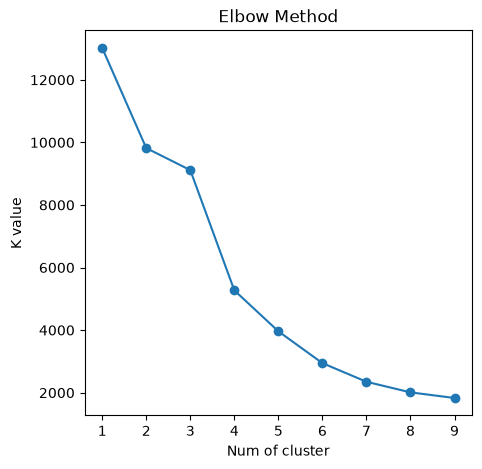

In [17]:
%pip install matplotlib
#plot inertia by elbow method
import matplotlib.pyplot as plt

inertia = []
K = range(1, 10)

for k in K:
    kmeans = KMeans(n_clusters = k, random_state = 1)
    kmeans.fit(rfm_scaler)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(5,5))
plt.plot(K, inertia, marker='o')
plt.title('Elbow Method')
plt.ylabel('K value')
plt.xlabel('Num of cluster')
plt.show()

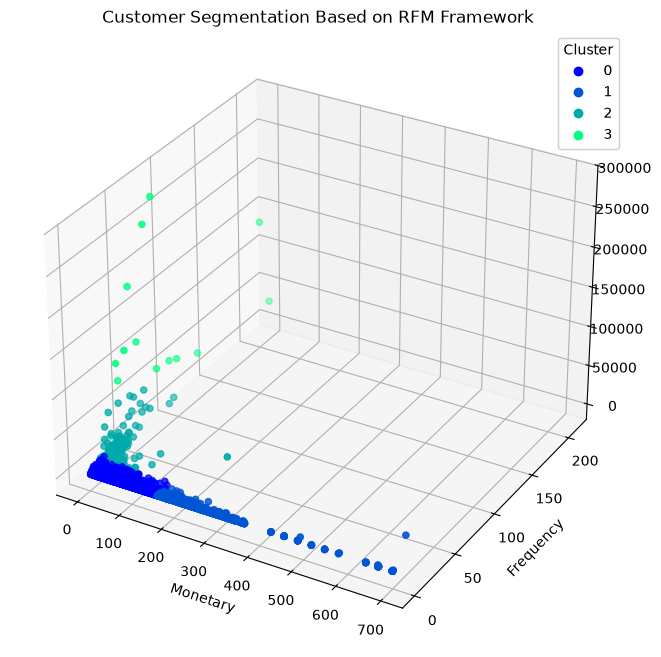

Silhouette score: 0.4532164302879254


In [18]:
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(rfm['Recency'], rfm['Frequency'], rfm['Monetary'], c=rfm['cluster'], cmap='winter')

ax.set_title('Customer Segmentation Based on RFM Framework')
ax.set_xlabel('Recency')
ax.set_ylabel('Frequency')
ax.set_xlabel('Monetary')
legend = ax.legend(*scatter.legend_elements(), title='Cluster')
ax.add_artist(legend)
plt.show()

# Calculate silhouette score
from sklearn.metrics import silhouette_score
s_score = silhouette_score(rfm_scaler, kmeans.labels_)
print("Silhouette score:", s_score)

In [19]:
# check details per cluster
cluster_0 = rfm[rfm['cluster'] == 0]
cluster_1 = rfm[rfm['cluster'] == 1]
cluster_2 = rfm[rfm['cluster'] == 2]
cluster_3 = rfm[rfm['cluster'] == 3]

print('Cluster 0 | Total count: 3009')
display(cluster_0)
print(f"Average Recency: {cluster_0['Recency'].mean()}\nAverage Frequency: {cluster_0['Frequency'].mean()}\nAverage Monetary: {cluster_0['Monetary'].mean()}")
print('-'*115)
print('Cluster 1 | Total count: 1109')
display(cluster_1)
print(f"Average Recency: {cluster_1['Recency'].mean()}\nAverage Frequency: {cluster_1['Frequency'].mean()}\nAverage Monetary: {cluster_1['Monetary'].mean()}")
print('-'*115)
print('Cluster 2 | Total count: 208')
display(cluster_2)
print(f"Average Recency: {cluster_2['Recency'].mean()}\nAverage Frequency: {cluster_2['Frequency'].mean()}\nAverage Monetary: {cluster_2['Monetary'].mean()}")
print('-'*115)
print('Cluster 3 | Total count: 13')
display(cluster_3)
print(f"Average Recency: {cluster_3['Recency'].mean()}\nAverage Frequency: {cluster_3['Frequency'].mean()}\nAverage Monetary: {cluster_3['Monetary'].mean()}")

Cluster 0 | Total count: 3009


,Recency,Frequency,Monetary,cluster
Customer ID,,,,
12347,40,7,4310.00,0
12348,76,4,1797.24,0
12349,19,1,1757.55,0
12352,73,8,2506.04,0
12355,96,1,459.40,0
...,...,...,...,...
18276,44,1,335.86,0
18277,0,1,110.38,0
18278,74,1,173.90,0


Average Recency: 52.21169823861748
Average Frequency: 3.7062146892655368
Average Monetary: 1352.9974187437688
-------------------------------------------------------------------------------------------------------------------
Cluster 1 | Total count: 1109


,Recency,Frequency,Monetary,cluster
Customer ID,,,,
12350,311,1,334.40,1
12353,204,1,89.00,1
12354,233,1,1079.40,1
12357,182,1,6207.67,1
12361,288,1,189.90,1
...,...,...,...,...
18250,311,1,349.27,1
18269,485,1,168.60,1
18270,267,2,283.15,1


Average Recency: 267.4688908926961
Average Frequency: 1.5509467989179442
Average Monetary: 496.3975933273219
-------------------------------------------------------------------------------------------------------------------
Cluster 2 | Total count: 208


,Recency,Frequency,Monetary,cluster
Customer ID,,,,
12346,326,1,77183.60,2
12431,2,15,6419.95,2
12437,9,18,4951.41,2
12471,11,30,19788.65,2
12474,3,18,7324.09,2
...,...,...,...,...
18198,72,17,5425.56,2
18223,40,14,6484.54,2
18229,0,20,7276.90,2


Average Recency: 17.096153846153847
Average Frequency: 22.0625
Average Monetary: 12558.217596153845
-------------------------------------------------------------------------------------------------------------------
Cluster 3 | Total count: 13


,Recency,Frequency,Monetary,cluster
Customer ID,,,,
12415,25,21,124914.53,3
12748,4,210,33053.19,3
13089,6,97,58762.08,3
14156,0,55,117210.08,3
14646,2,74,280206.02,3
14911,0,201,143711.17,3
15311,0,91,60632.75,3
16029,30,63,80850.84,3
16446,89,2,168472.50,3


Average Recency: 13.615384615384615
Average Frequency: 82.6923076923077
Average Monetary: 127187.95923076925


##### **Cluster 1: “Lost/Churned Customers” (1,109 customers)**
Business Characteristics: No transactions for nearly 9 months (Recency ~267 days). Averaged only 1.5 transactions with the lowest total spend (~496). These are customers who tried the service once and never returned.

Recommendation Category: Inactive / Churned Customers.

Business Strategy:

- Low-Cost Win-back Campaign: Avoid high marketing expenditures on this group. Instead, use automated email or WhatsApp blasts featuring "We miss you" messaging accompanied by a special discount.

##### **Cluster 0: "Core Active / Mass Shoppers" (3,009 customers)**
Business Characteristics: The volume backbone of the customer base (69.3% of total customers). They have transacted within the last 1–2 months (~52 days), averaging 3–4 shopping trips with a moderate spending contribution (~1,353).

Recommended Category: Active Everyday Customers or Core Retail.

Business Strategy:

- Upselling & Cross-selling: Drive transaction frequency from 3 to 5–6 trips using product recommendations based on purchase history.

- Standard Loyalty Program: Offer reward points or a general tiering system to encourage continued activity and prevent them from shifting to the "Lost" segment.

##### **Cluster 2: "High-Value VIPs" (208 customers)**
Business Characteristics: A high-value segment with high purchase frequency (averaging 22 transactions) and very recent activity (~17 days). Their total spending averages 12.5k (nearly 10 times that of Cluster 0).

Recommended Category: Loyal VIP Customers.

Business Strategy:

- VIP Loyalty Rewards: Offer priority access to new products, free shipping, or prioritized customer service.

- Retention Focus: Maintain high satisfaction levels within this segment to prevent them from switching to competitors, as these 208 accounts contribute a significant portion of profitability.

##### **Cluster 3: "Super Whales / Institutional B2B" (13 customers)**
Business Characteristics: A very small, elite group (13 accounts) possessing extraordinary purchasing power (~127k per customer) and a fantastic transaction frequency (~82 transactions). They have been active within the last two weeks (~13 days). These are not typical retail buyers but rather resellers, distributors, or business (B2B) accounts.

Recommended Category: Whale Accounts / B2B Distributors.

Business Strategy:

- Dedicated Account Manager: Personal outreach and management by a specialized sales/B2B team (avoiding automated systems).

- Volume Discounts & Credit Terms: Offer special wholesale pricing schemes or flexible payment terms based on contracts or long-term agreements.

In [20]:
# Mapping cluster'values to categorical value for ease the visualization
map_cluster_value = {
    1: 'Churned Customer',
    0: 'Casual Customer',
    2: 'Loyal VIP Customer (Power Users)',
    3: 'B2B Distributor'
}

rfm['segment_cust'] = rfm['cluster'].map(map_cluster_value)
rfm.head()

,Recency,Frequency,Monetary,cluster,segment_cust
Customer ID,,,,,
12346,326,1,77183.60,2,Loyal VIP Customer (Power Users)
12347,40,7,4310.00,0,Casual Customer
12348,76,4,1797.24,0,Casual Customer
12349,19,1,1757.55,0,Casual Customer
12350,311,1,334.40,1,Churned Customer


In [21]:
rfm = rfm.drop(columns=['cluster'])
rfm.head()

,Recency,Frequency,Monetary,segment_cust
Customer ID,,,,
12346,326,1,77183.60,Loyal VIP Customer (Power Users)
12347,40,7,4310.00,Casual Customer
12348,76,4,1797.24,Casual Customer
12349,19,1,1757.55,Casual Customer
12350,311,1,334.40,Churned Customer


In [22]:
# Export 2 files data (the first that call fact table, and rfm that call dimension table)
#Fact table
df.to_csv('Fact_Sales.csv', index=False)

#Dim table
rfm.reset_index().to_csv('Dim_Customer.csv', index=False)

print("file successfully exported")

file successfully exported


In [23]:
df

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,TotalSales
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-01-12 08:26:00,2.55,17850,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-01-12 08:26:00,3.39,17850,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-01-12 08:26:00,2.75,17850,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-01-12 08:26:00,3.39,17850,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-01-12 08:26:00,3.39,17850,United Kingdom,20.34
...,...,...,...,...,...,...,...,...,...
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-09-12 12:50:00,2.10,12680,France,12.60
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-09-12 12:50:00,4.15,12680,France,16.60
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-09-12 12:50:00,4.15,12680,France,16.60
541908,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,2011-09-12 12:50:00,4.95,12680,France,14.85
